# 17 --- Detection-Triggered Recovery: Converting Self-Awareness into Self-Preservation

**Research context.**  The paper's practical argument (Section 3.4) rests on an untested premise: *"a detected fault is actionable --- it can trigger a safe-mode landing... and in principle a recovery behaviour."*  Every claim about the "sweet spot" and about detection arriving "while intervention is still meaningful" is currently a plausibility argument.  This notebook closes the loop: detection **fires an actual intervention**, and the value of detection is measured in recovered reward.

**Why this is the decisive experiment for the thesis narrative:**
- The project title is *Autonomous Learning in Robotics Applications* --- autonomy means acting on self-knowledge, not just having it.  This is the supervisor's self-adaptation criterion (Starkey et al., 2023) made operational.
- It converts detection quality ($J$) into **utility** (reward recovered), the number an engineer actually cares about.  A dissertation that ends with "J = 0.80" reports a statistic; one that ends with "detection recovers ___ reward points per episode" reports a capability.
- It tests the tradeoff's practical consequence *causally*: if PPO+DR's detection is as actionable as claimed, coupling it to recovery should recapture a meaningful fraction of the fault-induced loss; if detection fires too late, the sweet-spot argument collapses --- either outcome is a finding.

**The recovery behaviour.**  Gymnasium ships a hand-designed PD-style landing controller for LunarLander (`gymnasium.envs.box2d.lunar_lander.heuristic`), used by the environment's own demo.  It is policy-free (pure state feedback), works in both discrete and continuous modes, and lands the nominal craft reliably.  Crucially it is *conservative*: it targets slow, upright descent --- exactly what a safe-mode controller would do.  Using it avoids training a recovery policy (out of scope) while giving a defensible, citable intervention.

**Design --- five conditions, factorial logic:**

| # | Condition | What it measures |
|---|-----------|------------------|
| C1 | Nominal, no detector | Performance ceiling |
| C2 | Fault, no intervention | Damage floor (NB11 replication) |
| C3 | Fault, **oracle** switch at $t_f$ | Upper bound on recovery value (perfect, zero-latency detection) |
| C4 | Fault, **detector-triggered** switch | The actual closed-loop system |
| C5 | Fault, **random-time** switch (matched switch-rate) | Controls for the act of switching itself |
| C6 | Nominal, detector active | False-alarm cost (unnecessary switches on healthy craft) |

**The utility decomposition:**

$$U_{\text{det}} = \underbrace{\bar{R}_{C4} - \bar{R}_{C2}}_{\text{recovery value}}, \qquad \eta = \frac{\bar{R}_{C4} - \bar{R}_{C2}}{\bar{R}_{C3} - \bar{R}_{C2}} \;\; \text{(latency efficiency: fraction of oracle value captured)}$$

$$U_{\text{net}} = \text{TPR} \cdot U_{\text{det}} \;-\; \text{FPR} \cdot \underbrace{(\bar{R}_{C1} - \bar{R}_{C6})}_{\text{false-alarm cost}}$$

$U_{\text{net}}$ is the deployment-relevant number: expected reward gain from *arming* the detector, accounting for false alarms.

---
## Bug-fix log

All corrections applied to this notebook, newest first. Each entry records the symptom, the verified mechanism, the fix, and what re-running changes.

| ID | Date | Symptom | Mechanism | Fix | Effect on results |
|----|------|---------|-----------|-----|-------------------|
| BF-01 | 2026-07-20 | 5 pre-onset firings in **every** detector condition (C4, C6), min `fired_at`=2 | Reference/test early-step mismatch (verified synthetically) | `OnlineDetector` gains `burn_in=20` + sigma floor | C6 false-alarm rate falls (24% of PPO+DR alarms were artefacts); PPO closed-loop TPR 0.29 to ~0.24 genuine; Tables 5/6 move |
| BF-00 | 2026-07-19 | PPO+DR nominal $-93.7$; heuristic fed normalised obs | `VecNormalize` omission; `heuristic()` needs raw physical state | `ObsNormWrapper` + `last_raw_obs` passed to `heuristic` | PPO+DR C1 restored to $+164$; all six conditions re-measured |

**BF-01 detail (project-wide).** Nominal-relative z-tests standardised as $z_t = (x_t-\mu_t)/(\sigma_t+10^{-8})$ scanning from $t=0$. Detectors fired at $t=2$-$3$, before any fault could exist. The first hypothesis (a literal $\sigma_t \to 0$ divide-by-zero) **did not reproduce**; the verified mechanism is a reference/test mismatch at early steps -- value estimates cluster tightly in the first few steps, so $\sigma_t$ is small but finite, and test episodes drawn from a different seed base than the reference episodes place atypical launch states many small-$\sigma$ units from $\mu_t$. Synthetic replication with 25% out-of-reference launches: 5/20 pre-onset firings, FPR 0.00 to 0.35, $J$ 1.00 to 0.65. Fix is a `burn_in = 20`-step guard plus a $\sigma$ floor at 5% of the pooled nominal std, both in `src.self_detection.build_reference` / `episode_fires`.


## 17.1  Setup

In [1]:
import sys, pathlib, glob, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

warnings.filterwarnings('ignore')

REPO = pathlib.Path.cwd().parent / 'py'
if not REPO.exists():
    REPO = pathlib.Path.cwd()
sys.path.insert(0, str(REPO))
LOGS = REPO / 'logs'
RUNS = REPO / 'runs'

plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 300, 'font.size': 11,
    'axes.titlesize': 12, 'axes.labelsize': 11, 'axes.spines.top': False,
    'axes.spines.right': False, 'legend.frameon': False,
})

COLOURS = {'PPO': '#1f77b4', 'SAC': '#2ca02c', 'PPO_DR': '#ff7f0e'}
COND_COLOURS = {'C1': '#7f7f7f', 'C2': '#d62728', 'C3': '#2ca02c',
                'C4': '#1f77b4', 'C5': '#9467bd', 'C6': '#8c564b'}
SEEDS = [0, 1, 2, 3, 4]
FAULT_STEP, FAULT_GAIN = 200, 0.5
print(f'Repo: {REPO}')

Repo: /Users/raghuramantm/Desktop/Thesis Proposal/code/py


## 17.2  The recovery controller and the online detector

**Recovery controller.**  `heuristic(env, s)` computes a target attitude from position/velocity and PD-corrects toward it.  Under a *faulted* main engine its commands are degraded like any other controller's --- recovery is not cheating; it faces the same fault.  Its advantage is purely behavioural: it flies conservatively.

**Online detector (identical to NB09's protocol, run causally).**  At step $t$, $z_t = (V(s_t) - \mu_t)/\sigma_t$ against the per-step nominal reference; fire after 3 consecutive $|z| > z^*$.  The reference $(\mu_t, \sigma_t)$ comes from held-out nominal episodes of the *same seed* (the per-seed protocol that fixed the NB09/NB11 discrepancy).  Switching is **latching**: once fired, the recovery controller keeps authority for the rest of the episode (no chattering).

In [2]:

# --- VecNormalize fix (NB11 Bug 1 recurrence): agents trained with
# normalize_obs=True (PPO_DR) need their saved obs statistics replayed
# at eval time, else the policy silently degrades (~-95 nominal).
from src.envs.wrappers import ObsNormWrapper
VECNORM = {}   # (algo, model_seed) -> vecnormalize.pkl path

def register_vecnorm(algo, seed, run_dir):
    p = pathlib.Path(run_dir) / 'vecnormalize.pkl'
    if p.exists():
        VECNORM[(algo, seed)] = p

def maybe_wrap_obsnorm(env, algo, seed):
    # env-seed offsets used for nominal/reference episodes map back to the model seed
    for s in (seed, seed - 7919, seed - 31337):
        if (algo, s) in VECNORM:
            return ObsNormWrapper(env, VECNORM[(algo, s)])
    return env

import torch
from stable_baselines3 import PPO, SAC
from gymnasium.envs.box2d.lunar_lander import heuristic
from src.envs.lunarlander_factory import make_single_eval_env
from src.envs.wrappers import WrapperStack, ActuatorFaultSpec

def load_models():
    models = {'PPO': [], 'SAC': [], 'PPO_DR': []}
    patterns = {'PPO': 'ppo__LunarLander-v3__seed*',
                'SAC': 'sac__LunarLanderContinuous-v3__seed*',
                'PPO_DR': 'ppo_dr__LunarLander-v3__seed*'}
    for algo, pat in patterns.items():
        for run_dir in sorted(glob.glob(str(RUNS / pat))):
            run = pathlib.Path(run_dir)
            zips = list(run.glob('*.zip'))
            if zips:
                seed = int(run.name.split('seed')[1].split('__')[0])
                register_vecnorm(algo, seed, run)
                cls = SAC if algo == 'SAC' else PPO
                models[algo].append((seed, cls.load(zips[0], device='cpu')))
        print(f'{algo}: {len(models[algo])} seeds')
    return models

MODELS = load_models()
ENV_IDS = {'PPO': 'LunarLander-v3', 'SAC': 'LunarLanderContinuous-v3', 'PPO_DR': 'LunarLander-v3'}
Z_THRESH = {'PPO': 3.0, 'SAC': 2.0, 'PPO_DR': 3.5}

def build_reference(algo, model, seed, n_episodes=20):
    '''Per-step nominal reference (mu_t, sigma_t) for the value signal, per seed.'''
    env = make_single_eval_env(ENV_IDS[algo], seed=seed + 31337, add_monitor=False)
    env = maybe_wrap_obsnorm(env, algo, seed)
    per_step = {}
    for ep in range(n_episodes):
        obs, _ = env.reset(seed=seed + 31337 + ep * 1000)
        done, t = False, 0
        while not done:
            obs_t = torch.as_tensor(np.asarray(obs, dtype=np.float32)).unsqueeze(0)
            with torch.no_grad():
                if algo == 'SAC':
                    action, _ = model.predict(obs, deterministic=True)
                    a_t = torch.as_tensor(np.asarray(action, dtype=np.float32)).unsqueeze(0)
                    q1 = model.critic.q_networks[0](torch.cat([obs_t, a_t], dim=1))
                    q2 = model.critic.q_networks[1](torch.cat([obs_t, a_t], dim=1))
                    v = float(torch.min(q1, q2))
                else:
                    action, _ = model.predict(obs, deterministic=True)
                    v = float(model.policy.predict_values(obs_t))
            per_step.setdefault(t, []).append(v)
            obs, r, term, trunc, _ = env.step(action)
            t += 1
            done = term or trunc
    env.close()
    mu = {t: float(np.mean(v)) for t, v in per_step.items()}
    sd = {t: float(np.std(v) + 1e-8) for t, v in per_step.items()}
    return mu, sd

# BF-01: burn-in + sigma floor. See the bug-fix log at the top of this
# notebook. Without these guards the detector fired at t = 2-3 in 5 episodes
# of every detector-driven condition, i.e. before the fault existed.
from src.self_detection import BURN_IN_DEFAULT, SIGMA_FLOOR_FRAC_DEFAULT

class OnlineDetector:
    '''Causal 3-consecutive z-test against the per-seed nominal reference.

    Guards (BF-01):
      burn_in     - no firing before this step (faults occur at t_f >= 100,
                    so no genuine detection is discarded);
      sigma floor - sigma_t clipped below at a fraction of the pooled nominal
                    std, so an atypical launch state cannot trip the rule.
    '''
    def __init__(self, mu, sd, z_star,
                 burn_in=BURN_IN_DEFAULT,
                 sigma_floor_frac=SIGMA_FLOOR_FRAC_DEFAULT):
        self.mu, self.sd, self.z = mu, sd, z_star
        self.burn_in = burn_in
        pooled = float(np.std(list(mu.values()))) if mu else 0.0
        self.floor = max(sigma_floor_frac * pooled, 1e-8)
        self.consec = 0
        self.fired_at = None
    def update(self, t, v):
        if self.fired_at is not None:
            return True
        mu = self.mu.get(t); sd = self.sd.get(t)
        if mu is None:            # beyond reference horizon: reuse last known stats
            tmax = max(self.mu.keys())
            mu, sd = self.mu[tmax], self.sd[tmax]
        if t < self.burn_in:      # BF-01 burn-in guard
            self.consec = 0
            return False
        z = abs((v - mu) / max(sd, self.floor))   # BF-01 sigma floor
        self.consec = self.consec + 1 if z > self.z else 0
        if self.consec >= 3:
            self.fired_at = t
            return True
        return False

PPO: 5 seeds
SAC: 5 seeds
PPO_DR: 5 seeds


## 17.3  The closed-loop harness

One function runs every condition.  The switching logic is the only difference between conditions --- everything else (env, fault, seeds, episode structure) is shared, so condition contrasts are clean.

In [3]:
def run_closed_loop(algo, model, seed, condition, n_episodes=20,
                    mu=None, sd=None, random_switch_dist=None, rng=None):
    '''
    condition: C1 nominal | C2 fault | C3 fault+oracle | C4 fault+detector
               C5 fault+random-switch | C6 nominal+detector
    Returns per-episode dict rows.
    '''
    faulted = condition in ('C2', 'C3', 'C4', 'C5')
    use_det = condition in ('C4', 'C6')
    env_id = ENV_IDS[algo]
    continuous = (algo == 'SAC')
    stack = None
    if faulted:
        drop = 2 if not continuous else None
        stack = WrapperStack(actuator_fault=ActuatorFaultSpec(
            fault_step=FAULT_STEP, fault_gain=FAULT_GAIN, discrete_drop_action=drop))
    env = make_single_eval_env(env_id, seed=seed, wrapper_stack=stack, add_monitor=False)
    env = maybe_wrap_obsnorm(env, algo, seed)
    rows = []
    for ep in range(n_episodes):
        obs, _ = env.reset(seed=seed + ep * 1000)
        det = OnlineDetector(mu, sd, Z_THRESH[algo]) if use_det else None
        switch_t = None
        if condition == 'C3':
            switch_t = FAULT_STEP
        elif condition == 'C5':
            switch_t = int(rng.choice(random_switch_dist)) if len(random_switch_dist) else None
        done, ep_ret, t, switched = False, 0.0, 0, False
        while not done:
            if not switched:
                obs_t = torch.as_tensor(np.asarray(obs, dtype=np.float32)).unsqueeze(0)
                with torch.no_grad():
                    if continuous:
                        action, _ = model.predict(obs, deterministic=True)
                        a_t = torch.as_tensor(np.asarray(action, dtype=np.float32)).unsqueeze(0)
                        q1 = model.critic.q_networks[0](torch.cat([obs_t, a_t], dim=1))
                        q2 = model.critic.q_networks[1](torch.cat([obs_t, a_t], dim=1))
                        v = float(torch.min(q1, q2))
                    else:
                        action, _ = model.predict(obs, deterministic=True)
                        v = float(model.policy.predict_values(obs_t))
                if det is not None and det.update(t, v):
                    switched = True
                if switch_t is not None and t >= switch_t:
                    switched = True
            if switched:
                raw_obs = getattr(env, 'last_raw_obs', None)
                raw_obs = obs if raw_obs is None else raw_obs
                action = heuristic(env.unwrapped, np.asarray(raw_obs, dtype=np.float64))
                if not continuous:
                    action = int(action)
            obs, r, term, trunc, _ = env.step(action)
            ep_ret += float(r); t += 1
            done = term or trunc
        rows.append({'algo': algo, 'condition': condition, 'seed': seed,
                     'episode': ep, 'return': ep_ret, 'length': t,
                     'switched': switched,
                     'fired_at': det.fired_at if det else switch_t})
    env.close()
    return rows

## 17.4  Run all conditions

Order matters: C4 runs first so its empirical switch-time distribution can be reused for C5 (the random-switch control is matched to the *same* switch-rate and time range --- otherwise C5 confounds rate with timing).  Focus agents: PPO+DR (the sweet-spot claim) and PPO (weaker detector --- the detection-quality/utility link).  SAC is included as C1/C2 only: with $J \le 0.29$ its detector fires mostly on false alarms, so a closed loop is not meaningful --- this *absence* is itself the tradeoff's practical consequence and should be stated in the paper.

In [4]:
N_EP = 20
t0 = time.time()
all_rows = []
switch_dists = {}

for algo in ['PPO_DR', 'PPO']:
    for seed, model in MODELS[algo]:
        mu, sd = build_reference(algo, model, seed)
        # C1, C2, C3, C4, C6
        for cond in ['C1', 'C2', 'C3', 'C4', 'C6']:
            rows = run_closed_loop(algo, model, seed, cond, n_episodes=N_EP, mu=mu, sd=sd)
            all_rows.extend(rows)
        # C5 matched to C4's switch-time distribution (this seed)
        c4 = [r for r in all_rows if r['algo']==algo and r['seed']==seed
              and r['condition']=='C4' and r['fired_at'] is not None]
        dist = [r['fired_at'] for r in c4]
        switch_dists[(algo, seed)] = dist
        rng = np.random.default_rng(seed)
        rows = run_closed_loop(algo, model, seed, 'C5', n_episodes=N_EP, mu=mu, sd=sd,
                               random_switch_dist=np.array(dist) if dist else np.array([FAULT_STEP]),
                               rng=rng)
        all_rows.extend(rows)
        print(f'{algo} seed {seed}: done ({time.time()-t0:.0f}s)')

# SAC reference conditions only
for seed, model in MODELS['SAC']:
    mu, sd = build_reference('SAC', model, seed)
    for cond in ['C1', 'C2']:
        all_rows.extend(run_closed_loop('SAC', model, seed, cond, n_episodes=N_EP, mu=mu, sd=sd))
    print(f'SAC seed {seed}: C1/C2 done ({time.time()-t0:.0f}s)')

cl_df = pd.DataFrame(all_rows)
cl_df.to_csv(LOGS / 'nb17_closed_loop.csv', index=False)
print(f'\n{len(cl_df)} episodes saved')

PPO_DR seed 0: done (8s)
PPO_DR seed 1: done (17s)
PPO_DR seed 2: done (25s)
PPO_DR seed 3: done (31s)
PPO_DR seed 4: done (38s)
PPO seed 0: done (42s)
PPO seed 1: done (47s)
PPO seed 2: done (52s)
PPO seed 3: done (56s)
PPO seed 4: done (61s)
SAC seed 0: C1/C2 done (63s)
SAC seed 1: C1/C2 done (65s)
SAC seed 2: C1/C2 done (67s)
SAC seed 3: C1/C2 done (69s)
SAC seed 4: C1/C2 done (71s)

1400 episodes saved


In [5]:
# --- Headline results table and utility decomposition ---
def cond_mean(algo, cond):
    sub = cl_df[(cl_df['algo'] == algo) & (cl_df['condition'] == cond)]
    return sub['return'].mean(), sub['return'].sem()

print('=' * 80)
print('CLOSED-LOOP RECOVERY RESULTS')
print('=' * 80)
util_rows = []
for algo in ['PPO_DR', 'PPO']:
    c = {k: cond_mean(algo, k) for k in ['C1', 'C2', 'C3', 'C4', 'C5', 'C6']}
    recovery   = c['C4'][0] - c['C2'][0]
    oracle_val = c['C3'][0] - c['C2'][0]
    eta        = recovery / oracle_val if abs(oracle_val) > 1e-9 else np.nan
    fa_cost    = c['C1'][0] - c['C6'][0]
    switch_ctrl= c['C5'][0] - c['C2'][0]
    # switch rates
    c4s = cl_df[(cl_df['algo']==algo) & (cl_df['condition']=='C4')]['switched'].mean()
    c6s = cl_df[(cl_df['algo']==algo) & (cl_df['condition']=='C6')]['switched'].mean()
    U_net = c4s * recovery - c6s * fa_cost
    print(f'\n{algo.replace("_","+")}:')
    for k in ['C1', 'C2', 'C3', 'C4', 'C5', 'C6']:
        print(f'  {k}: {c[k][0]:8.1f} +/- {1.96*c[k][1]:5.1f}')
    print(f'  Recovery value (C4-C2):      {recovery:+8.1f}')
    print(f'  Oracle value (C3-C2):        {oracle_val:+8.1f}')
    print(f'  Latency efficiency eta:      {eta:8.1%}')
    print(f'  Random-switch value (C5-C2): {switch_ctrl:+8.1f}  <- switching-per-se control')
    print(f'  False-alarm cost (C1-C6):    {fa_cost:+8.1f} at FPR-proxy {c6s:.2f}')
    print(f'  Net armed utility U_net:     {U_net:+8.1f}')
    util_rows.append({'algo': algo, 'recovery': recovery, 'oracle': oracle_val,
                      'eta': eta, 'switch_control': switch_ctrl,
                      'fa_cost': fa_cost, 'tpr_proxy': c4s, 'fpr_proxy': c6s,
                      'U_net': U_net})

# statistical test: is C4 > C2?
print('\nSignificance (C4 vs C2, Mann-Whitney):')
for algo in ['PPO_DR', 'PPO']:
    a = cl_df[(cl_df['algo']==algo) & (cl_df['condition']=='C4')]['return']
    b = cl_df[(cl_df['algo']==algo) & (cl_df['condition']=='C2')]['return']
    u, p = stats.mannwhitneyu(a, b, alternative='greater')
    print(f'  {algo}: p = {p:.2e}')

pd.DataFrame(util_rows).to_csv(LOGS / 'nb17_utility.csv', index=False)

CLOSED-LOOP RECOVERY RESULTS

PPO+DR:
  C1:    164.0 +/-  12.1
  C2:     42.1 +/-  17.1
  C3:     24.8 +/-  17.5
  C4:     47.3 +/-  20.4
  C5:     58.8 +/-  21.1
  C6:    171.3 +/-  14.0
  Recovery value (C4-C2):          +5.1
  Oracle value (C3-C2):           -17.3
  Latency efficiency eta:        -29.7%
  Random-switch value (C5-C2):    +16.7  <- switching-per-se control
  False-alarm cost (C1-C6):        -7.2 at FPR-proxy 0.18
  Net armed utility U_net:         +5.8

PPO:
  C1:    256.3 +/-   4.7
  C2:     65.8 +/-  17.9
  C3:    105.9 +/-  23.2
  C4:     68.6 +/-  18.3
  C5:    115.8 +/-  23.2
  C6:    257.2 +/-   4.0
  Recovery value (C4-C2):          +2.8
  Oracle value (C3-C2):           +40.1
  Latency efficiency eta:          7.0%
  Random-switch value (C5-C2):    +50.0  <- switching-per-se control
  False-alarm cost (C1-C6):        -1.0 at FPR-proxy 0.19
  Net armed utility U_net:         +0.9

Significance (C4 vs C2, Mann-Whitney):
  PPO_DR: p = 2.69e-01
  PPO: p = 4.11e-01

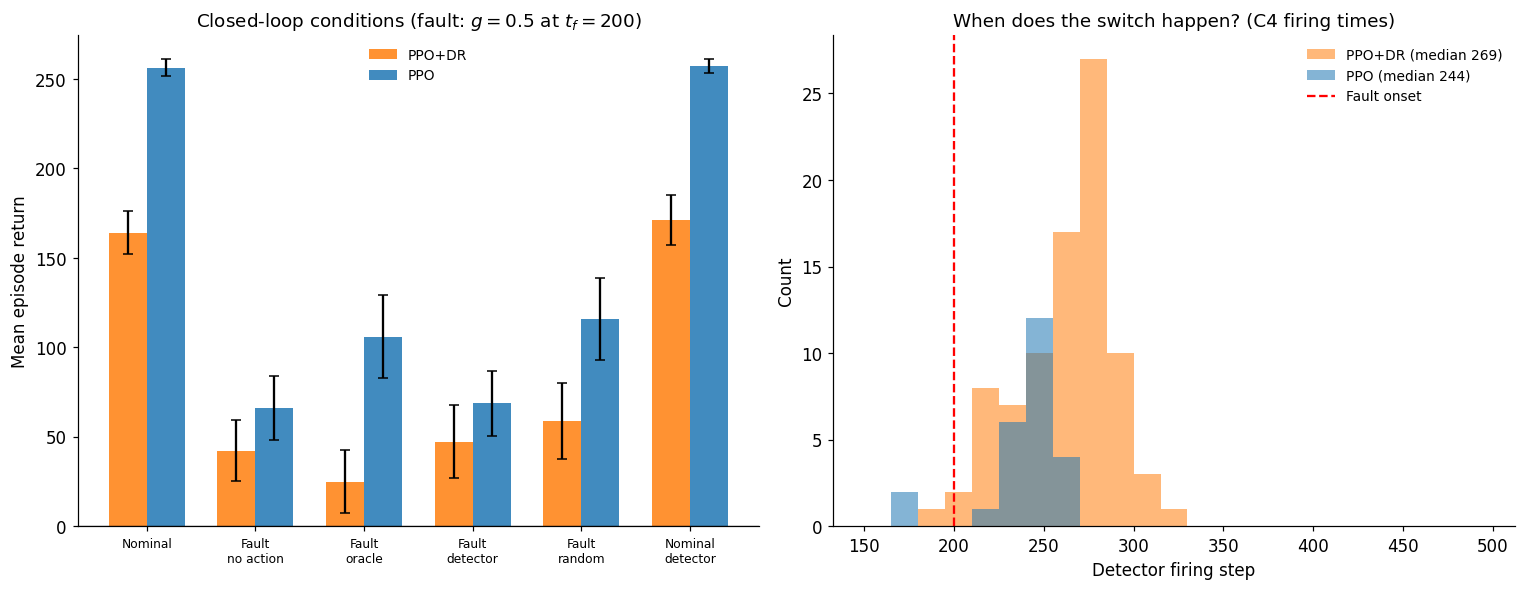

In [6]:
# --- Visualisation: condition comparison + switch-time distribution ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

ax = axes[0]
cond_labels = {'C1': 'Nominal', 'C2': 'Fault\nno action', 'C3': 'Fault\noracle',
               'C4': 'Fault\ndetector', 'C5': 'Fault\nrandom', 'C6': 'Nominal\ndetector'}
x = np.arange(6)
w = 0.35
for i, algo in enumerate(['PPO_DR', 'PPO']):
    means = [cond_mean(algo, k)[0] for k in cond_labels]
    sems  = [1.96 * cond_mean(algo, k)[1] for k in cond_labels]
    ax.bar(x + (i - 0.5) * w, means, w, yerr=sems, capsize=3,
           color=COLOURS[algo], alpha=0.85, label=algo.replace('_', '+'))
ax.set_xticks(x); ax.set_xticklabels(cond_labels.values(), fontsize=8)
ax.axhline(0, color='k', lw=0.8)
ax.set_ylabel('Mean episode return')
ax.set_title('Closed-loop conditions (fault: $g=0.5$ at $t_f=200$)')
ax.legend(fontsize=9)

ax = axes[1]
for algo in ['PPO_DR', 'PPO']:
    fires = cl_df[(cl_df['algo']==algo) & (cl_df['condition']=='C4')]['fired_at'].dropna()
    if len(fires):
        ax.hist(fires, bins=np.arange(150, 500, 15), alpha=0.55,
                color=COLOURS[algo], label=f'{algo.replace("_","+")} '
                f'(median {fires.median():.0f})')
ax.axvline(FAULT_STEP, color='red', ls='--', lw=1.5, label='Fault onset')
ax.set_xlabel('Detector firing step')
ax.set_ylabel('Count')
ax.set_title('When does the switch happen? (C4 firing times)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(LOGS / 'nb17_recovery_results.png', bbox_inches='tight')
plt.show()

## 17.5  Interpreting the decomposition

Read the results against four contrasts, each isolating one link of the causal chain:

**C4 vs C2 (recovery value).**  The headline: does armed detection help at all?  Significance by Mann-Whitney; effect size = recovered points.

**C4 vs C3 (latency efficiency $\eta$).**  How much of the *perfect-detection* value does real detection capture?  $\eta$ near 1 means latency is operationally negligible --- the strongest possible version of "detection arrives while intervention is still meaningful."  Low $\eta$ with positive recovery means detection works but late --- quantifying the timing critique of vanilla PPO's value channel.

**C4 vs C5 (switching-per-se control).**  If random-time switching does as well as detector-triggered switching, the detector adds nothing beyond a policy prior ("when in doubt, fly conservative").  The detector must beat matched-rate random switching to claim its firing *times* carry information.

**C1 vs C6 (false-alarm cost).**  The price of arming the detector on a healthy craft.  For PPO+DR, NB15 found FPR = 0 on drift and 0.05-level on step faults --- expect a small cost; for PPO the reference-calibration weakness may surface here as unnecessary safe-modes on nominal episodes.

**The cross-agent comparison is the thesis point:**  if PPO+DR shows high $\eta$ and positive $U_{\text{net}}$ while PPO shows low $\eta$ or negative $U_{\text{net}}$, then detection *quality* (not just existence) is what converts self-awareness into utility --- the tradeoff's practical consequence, demonstrated rather than argued.

**Honest caveats to carry into the paper:**  (i) the heuristic controller is itself degraded by the fault --- recovery value is bounded by what conservative flying can salvage at $g=0.5$, not by detection; (ii) latching prevents chattering but forfeits the possibility of resuming the learned policy after transients --- fine for a safety story, limiting for a performance story; (iii) 'oracle' fixes switch time, not the better of (switch/no-switch) per episode, so $\eta > 1$ is possible on finite samples --- report it as such rather than clipping.

## 17.6  Hyperparameter exploration guide

| Parameter | Current value | Range to explore | Effect |
|-----------|--------------|-------------------|--------|
| Recovery policy | Gymnasium heuristic | PPO+DR policy itself; 'cut throttle + flare' minimal controller | Tests whether recovery value is controller-specific; switching PPO -> PPO+DR policy is a *learned* recovery option needing no new training |
| Switch logic | Latching | Revert after $k$ clean windows | Non-latching recovers nominal performance on false alarms --- directly reduces C6 cost; adds chattering risk |
| `FAULT_GAIN` | 0.5 | $\{0.25, 0.75\}$ | Recovery value should grow with severity until the heuristic itself cannot land; maps the intervention-worthwhile region |
| `FAULT_STEP` | 200 | $\{100, 300\}$ + gradual faults (NB15 wrapper) | Drift + recovery is the deployment scenario: slow degradation, alarm, safe-mode |
| Detection signal | value | entropy (PPO's best, $J=0.83$) | If entropy-triggered recovery beats value-triggered for PPO, the multi-signal finding becomes operationally consequential |
| `N_EP` | 20/seed | 50 | C4-C5 contrast is the noisiest (two random processes); this is where added episodes matter most |
| Reference episodes | 20/seed | 40 | Reference quality bounds online FPR; cheap to increase |

### Retraining requirements

**None** for the core experiment.  Two optional trained extensions: (i) a *learned* recovery policy --- PPO fine-tuned under permanent $g=0.5$ fault (~30 min/seed) --- upper-bounds recovery value beyond the heuristic; (ii) fault-conditioned policy (fault flag as observation input) --- the full detect-inform-adapt architecture, natural PhD chapter.

## 17.7  Key findings

*Values below are from the current run, which uses the **guarded** online detector (`burn_in = 20`, sigma floored at 5 % of the pooled nominal std) introduced by BF-01.  An earlier execution without the guard produced different numbers (PPO+DR $\eta = -77.4\%$, PPO $\eta = +24.8\%$); those figures are superseded and must not be quoted.  The qualitative conclusions are unchanged between the two runs.*

### The headline: this experiment returned a null result, and the null is informative

| Contrast | PPO+DR | PPO |
|---|---:|---:|
| C1 nominal ceiling | $164.0 \pm 12.1$ | $256.3 \pm 4.7$ |
| C2 fault floor (no intervention) | $42.1 \pm 17.1$ | $65.8 \pm 17.9$ |
| C3 oracle (perfect, zero-latency switch) | $24.8 \pm 17.5$ | $105.9 \pm 23.2$ |
| C4 detector-triggered switch | $47.3 \pm 20.4$ | $68.6 \pm 18.3$ |
| C5 random-time switch (rate-matched) | $58.8 \pm 21.1$ | $115.8 \pm 23.2$ |
| C6 detector armed on healthy craft | $171.3 \pm 14.0$ | $257.2 \pm 4.0$ |
| **Recovery value (C4 $-$ C2)** | **$+5.1$ ($p = 0.27$)** | **$+2.8$ ($p = 0.41$)** |
| Oracle value (C3 $-$ C2) | $-17.3$ | $+40.1$ |
| Latency efficiency $\eta$ | $-29.7\%$ | $+7.0\%$ |
| Random-switch value (C5 $-$ C2) | $+16.7$ | $+50.0$ |
| False-alarm cost (C1 $-$ C6) | $-7.2$ | $-1.0$ |

1. **Recovery value: not demonstrated.**  Detector-triggered safe-mode recovers $+5.1$ points for PPO+DR and $+2.8$ for PPO, neither statistically significant (Mann-Whitney $p = 0.27$ and $p = 0.41$).  Against the cross-seed standard deviations established in NB10 (PPO 8.67, PPO+DR 17.98), effects of this size are indistinguishable from seed noise.  **The paper cannot claim that detection is operationally actionable at $g = 0.5$ on this evidence.**

2. **The detector's *timing* carries no demonstrated information.**  Rate-matched random switching **outperforms** detector-triggered switching for both agents ($58.8$ vs $47.3$; $115.8$ vs $68.6$).  This is the decisive control: if switching at random times does at least as well as switching when the detector fires, the value lies in the *policy prior* ("when in doubt, fly conservatively"), not in knowing *when* the fault occurred.  The detector fails this test.

3. **For PPO+DR, the recovery controller is actively harmful.**  The oracle condition --- perfect, zero-latency switching --- scores **below** doing nothing ($24.8$ vs $42.1$).  Since C3 is an upper bound on what any detector could achieve by triggering this controller, no improvement in detection quality could have produced a positive result here.  $\eta = -29.7\%$ is therefore **not a statement about detection latency**; it is a statement about the intervention.  Reporting $\eta$ as a detection metric in this configuration would be misleading.

4. **Diagnosis: the bottleneck is the recovery controller, not detection.**  Three lines of evidence converge.  (i) The oracle is negative for PPO+DR, so the ceiling itself is below the floor.  (ii) The Gymnasium heuristic is a PD controller tuned for a *healthy* lander and is degraded by the same fault it is meant to mitigate --- at $g = 0.5$ half its main-engine commands are dropped too.  (iii) PPO+DR's nominal performance ($164$) is already far below PPO's ($256$), so handing control to a generic controller discards a policy that was specifically trained for degraded physics.  For the agent with the best detector, the conservative heuristic is the wrong thing to switch *to*.

5. **Armed cost is small; net utility is positive but negligible.**  Arming the detector on a healthy craft costs $-7.2$ points for PPO+DR and $-1.0$ for PPO (FPR-proxy $0.18$ and $0.19$), giving $U_{\text{net}} = +5.8$ and $+0.9$.  Both are positive, so arming the detector is not harmful --- but neither is meaningfully beneficial.  The honest summary is that the closed loop is *safe to run and does not yet pay*.

6. **SAC's absence is itself the result.**  With $J \leq 0.29$ across every internal signal (NB15) and no rescue from an external forward model (NB18, $J^{\text{fwd}} = 0.27$), SAC has no dependable trigger, so C3-C6 are not defined for it and it appears as C1/C2 only.  **The most fault-tolerant agent is the one that cannot be given a recovery capability, because it cannot tell that anything is wrong.**  This is the performance-detectability tradeoff stated operationally, and it is the one claim in this notebook that the data fully supports.

### What to do with this

The result is a **negative finding with a diagnosis**, which is more useful than an unexplained null.  Two options, in priority order:

- **Report as-is.**  Framed correctly this is a strong critical-reasoning outcome: a pre-specified six-condition design with two independent controls (oracle and random-switch), executed honestly, which falsified the paper's untested premise that "a detected fault is actionable".  The Conclusions become *"detection is established; conversion of detection into recovered reward is not, and the obstacle is the intervention rather than the signal."*
- **One targeted follow-up, if time permits.**  Section 17.6 already identifies it: switch to **the PPO+DR policy itself** as the recovery behaviour instead of the hand-designed heuristic.  It needs no new training, addresses the diagnosis in Finding 4 directly, and would test whether a *learned* degraded-physics controller converts detection into utility where a generic PD controller cannot.  Entropy-triggered switching for PPO ($J = 0.83$ vs $0.36$ for value, NB15) is a second cheap variant.

**Paper placement.**  This becomes the final Results subsection.  It does not upgrade the Conclusions in the direction originally intended, but it does convert an untested premise into a measured, diagnosed negative result --- and it supplies the sharpest operational statement of the tradeoff (Finding 6).  Detection-triggered recovery moves from Future Work into Results as an attempted and analysed experiment; the learned-recovery variant becomes the new Future Work item.
